# 🔬 Experiment Set 2 — Unit Variation Test
## Unit Awareness & Engineering Correctness

---

## Dataset Used: `rfp_specs_unit_variation.csv` (Variant 7)

**Why this dataset and NOT the others:**

| Dataset | Why NOT used here |
|---|---|
| Clean base | No unit variation — baseline only |
| Numeric Perturbation | Values are WRONG (Exp 1). Here values are CORRECT, just written differently |
| In/Out-of-domain noise | Tests filler text, not unit notation |
| Long-doc / Positional / Missing | Different stress dimensions |
| **Unit Variation (Variant 7)** | **Same meaning, different notation: `11kV` vs `11000V`, `240 sqmm` vs `240 mm²`, `3C` vs `3 Core`, `Cu` vs `Copper`** |

## What This Experiment Tests

- `11kV` and `11000V` are the **same voltage** — a unit-aware model should score them identically
- `240 sqmm` and `240 mm²` are the **same cross-section**
- `3C` and `3 Core` are the **same core count**

**SBERT failure mode:** `11kV` and `11000V` have different token representations → different embedding regions → **confused**

**Hybrid advantage:** Structured columns (`voltage_rating`, etc.) are **never changed** → always correct → **unit-aware by design**

## Metrics
1. **Unit Equivalence Score (UES)** — does score stay stable across unit variants?
2. **Score Stability (ΔScore)** — how much does compliance change? (should be ~0)
3. **Rank Stability** — does Top-1 SKU remain the same?
4. **Full IR Metrics** — Top-1, Top-5, MRR, NDCG@5 on unit-varied vs clean
5. **Per-Transform Breakdown** — which unit conversion hurts which model most

In [ ]:
# CELL 1 — INSTALL
!pip install -q sentence-transformers scikit-learn rank-bm25 pandas numpy matplotlib tabulate pyarrow

In [ ]:
# CELL 2 — IMPORTS
import os, json, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from typing import Dict, Optional, Tuple
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi

warnings.filterwarnings('ignore')
np.random.seed(42)

ARTIFACT_DIR = 'obj1_model_artifacts'
EXP_DIR      = 'exp2_unit_variation'
os.makedirs(EXP_DIR, exist_ok=True)
print('✅ Imports done.')

✅ Imports done.


In [ ]:
# CELL 3 — LOAD ARTIFACTS + DATASETS
# Upload to Colab:
#   obj1_model_artifacts/        (from Objective 1)
#   rfp_specs_7000.csv           (clean baseline)
#   rfp_specs_unit_variation.csv (Variant 7)
#   product_catalog.csv

cfg         = json.load(open(f'{ARTIFACT_DIR}/model_config.json'))
product_df  = pd.read_parquet(f'{ARTIFACT_DIR}/product_df.parquet')
rfp_gt_df   = pd.read_parquet(f'{ARTIFACT_DIR}/rfp_df_with_gt.parquet')
product_emb = np.load(f'{ARTIFACT_DIR}/product_embeddings_mpnet.npy')
baseline_df = pd.read_csv(f'{ARTIFACT_DIR}/baseline_results.csv')

df_clean = pd.read_csv('rfp_specs_7000.csv').reset_index(drop=True)
df_unit  = pd.read_csv('rfp_specs_unit_variation.csv').reset_index(drop=True)

for df in [df_clean, df_unit, product_df]:
    df.columns = df.columns.str.strip()

gt_lookup = (
    rfp_gt_df.dropna(subset=['ground_truth_sku'])
    .drop_duplicates('rfp_id')
    .set_index('rfp_id')['ground_truth_sku']
    .to_dict()
)

N_RFP = len(df_clean)
N_SKU = len(product_df)
K     = cfg['K']
changed_mask = (df_clean['spec_text_raw'] != df_unit['spec_text_raw']).values
n_changed    = changed_mask.sum()

print(f'Product catalog      : {product_df.shape}')
print(f'Clean RFP specs      : {df_clean.shape}')
print(f'Unit-varied specs    : {df_unit.shape}')
print(f'Rows with unit change: {n_changed} / {N_RFP} ({n_changed/N_RFP*100:.1f}%)')
print(f'GT entries           : {len(gt_lookup)}')
print(f'K                    : {K}')
print(f'Hybrid weights       : {cfg["hybrid_weights"]}')
print('\nObj 1 Baseline (reference):')
print(baseline_df[['Model','Top-1 Acc','MRR','NDCG@5']].to_string(index=False))

Product catalog      : (200, 16)
Clean RFP specs      : (7000, 17)
Unit-varied specs    : (7000, 17)
Rows with unit change: 4831 / 7000 (69.0%)
GT entries           : 7000
K                    : 5
Hybrid weights       : {'structured': 0.5, 'semantic': 0.3, 'standards': 0.2}

Obj 1 Baseline (reference):
                    Model  Top-1 Acc      MRR   NDCG@5
       1. Random Baseline   0.004571 0.029806 0.016021
       2. TF-IDF + Cosine   0.115429 0.231303 0.220847
          3. BM25 (Okapi)   0.055857 0.165056 0.148266
       4. SBERT MiniLM-L6   0.132571 0.231357 0.231525
5. SBERT MPNet (sem-only)   0.165286 0.260932 0.248361
6. Exact Structured Match   0.057000 0.129356 0.116747
       7. 🏆 Hybrid (Ours)   0.178000 0.308767 0.312451


In [ ]:
# CELL 4 — UNIT TRANSFORM ANALYSIS
import re

def detect_transforms(orig, pert):
    orig_kv = set(re.findall(r'\b\d+(?:\.\d+)?kV\b', orig))
    pert_kv = set(re.findall(r'\b\d+(?:\.\d+)?kV\b', pert))
    orig_nv = set(re.findall(r'\b\d{3,6}V\b', orig))
    pert_nv = set(re.findall(r'\b\d{3,6}V\b', pert))
    voltage_changed = (orig_kv != pert_kv) or (orig_nv != pert_nv)
    area_changed = ('sqmm' in orig) != ('sqmm' in pert)
    orig_cores = set(re.findall(r'\b(\d+)C\b', orig))
    pert_cores = set(re.findall(r'\b(\d+)C\b', pert))
    core_changed = orig_cores != pert_cores
    cu_changed = ('Cu ' in orig) != ('Cu ' in pert)
    al_changed = (' Al ' in orig) != (' Al ' in pert)
    n = sum([voltage_changed, area_changed, core_changed, cu_changed, al_changed])
    return {'voltage_unit': voltage_changed, 'area_unit': area_changed,
            'core_notation': core_changed, 'cu_notation': cu_changed,
            'al_notation': al_changed, 'n_transforms': n, 'any_changed': n > 0}

transform_rows = []
for i in range(N_RFP):
    d = detect_transforms(str(df_clean.loc[i,'spec_text_raw']), str(df_unit.loc[i,'spec_text_raw']))
    d['rfp_id']    = df_clean.loc[i,'rfp_id']
    d['orig_text'] = df_clean.loc[i,'spec_text_raw']
    d['unit_text'] = df_unit.loc[i,'spec_text_raw']
    transform_rows.append(d)

tr_df = pd.DataFrame(transform_rows)

print('=== Unit Transform Breakdown ===')
for col in ['voltage_unit','area_unit','core_notation','cu_notation','al_notation']:
    print(f'  {col:18s}: {tr_df[col].sum():5d} ({tr_df[col].mean()*100:.1f}%)')
print(f'  {"Any transform":18s}: {tr_df.any_changed.sum():5d} ({tr_df.any_changed.mean()*100:.1f}%)')
print('\nRows by number of transforms:')
print(tr_df[tr_df.any_changed].groupby('n_transforms').size().rename('count').to_string())
print('\n--- Key examples per transform ---')
for t in ['voltage_unit','area_unit','core_notation','cu_notation','al_notation']:
    rows_t = tr_df[tr_df[t]]
    if len(rows_t) == 0: continue
    row = rows_t.iloc[0]
    print(f'[{t}]')
    print(f'  ORIG: {row.orig_text}')
    print(f'  UNIT: {row.unit_text}')
    print()

=== Unit Transform Breakdown ===
  voltage_unit      :  1765 (25.2%)
  area_unit         :  1822 (26.0%)
  core_notation     :  1745 (24.9%)
  cu_notation       :  1415 (20.2%)
  al_notation       :   295 (4.2%)
  Any transform     :  4831 (69.0%)

Rows by number of transforms:
n_transforms
1    2996
2    1477
3     340
4      18

--- Key examples per transform ---
[voltage_unit]
  ORIG: 500V 5C 2.5 sqmm Cu XLPE armoured cable as per IEC 60502-1
  UNIT: 0.5kV 5C 2.5 sqmm Cu XLPE armoured cable as per IEC 60502-1

[area_unit]
  ORIG: 1.1kV 8C 6 sqmm Cu PVC armoured cable as per BS 5308
  UNIT: 1.1kV 8C 6 mm² Cu PVC armoured cable as per BS 5308

[core_notation]
  ORIG: FRLS 1.1kV 4C 0.75 sqmm Cu PVC armoured cable as per IEC 60502-1
  UNIT: FRLS 1.1kV 4 Core 0.75 sqmm Cu PVC armoured cable as per IEC 60502-1

[cu_notation]
  ORIG: FRLS 3.3kV 1C 50 sqmm Cu EPR armoured cable as per IS 7098-1
  UNIT: FRLS 3.3kV 1C 50 sqmm Copper EPR armoured cable as per IS 7098-1

[al_notation]
  ORIG: Z

In [ ]:
# CELL 5 — SHARED SCORING FUNCTIONS
_SIZE_LADDER = [0.5,0.75,1.0,1.5,2.5,4.0,6.0,10.0,16.0,25.0,35.0,50.0,70.0,95.0,
                120.0,150.0,185.0,240.0,300.0,400.0,500.0,630.0,800.0,1000.0]
_SIZE_SET = set(_SIZE_LADDER)

def _adjacent_sizes(val):
    if val not in _SIZE_SET: val = min(_SIZE_LADDER, key=lambda x: abs(x-val))
    idx = _SIZE_LADDER.index(val)
    n = {val}
    if idx > 0: n.add(_SIZE_LADDER[idx-1])
    if idx < len(_SIZE_LADDER)-1: n.add(_SIZE_LADDER[idx+1])
    return n

def structured_score(rfp_row, sku_row):
    mandatory = set(f.strip() for f in str(rfp_row.get('mandatory_specs','')).split(';') if f.strip())
    score = total = 0.0
    for field in cfg['exact_fields']:
        w = 2.0 if field in mandatory else 1.0
        total += w
        if str(rfp_row.get(field,'')).strip().lower() == str(sku_row.get(field,'')).strip().lower():
            score += w
    w_cc = 2.0 if 'core_count' in mandatory else 1.0
    total += w_cc
    try:
        if int(float(rfp_row['core_count'])) == int(float(sku_row['core_count'])): score += w_cc
    except: pass
    w_sz = 2.0 if 'size_sqmm' in mandatory else 1.0
    total += w_sz
    try:
        if float(sku_row['size_sqmm']) in _adjacent_sizes(float(rfp_row['size_sqmm'])): score += w_sz
    except: pass
    return score/total if total > 0 else 0.0

def standards_score(rfp_row, sku_row):
    r = str(rfp_row.get('standards_required','')).strip().lower()
    s = str(sku_row.get('standards_complied','')).strip().lower()
    if not r or r == 'nan': return 0.0
    return 1.0 if (r in s or s in r) else 0.0

def compute_metrics(match_groups, gt_lookup, score_key='hybrid', weights=None, K=5):
    top1 = topk = mrr_sum = prec_sum = ndcg_sum = 0.0
    evaluated = 0
    for rfp_id, grp in match_groups.items():
        gt = gt_lookup.get(rfp_id)
        if gt is None: continue
        sku_ids = grp['sku_id']
        if weights:
            ws, we, wt = weights
            scores = ws*grp['structured'] + we*grp['semantic'] + wt*grp['standards']
        else:
            scores = grp[score_key]
        order  = np.lexsort((sku_ids, -scores))
        ranked = sku_ids[order]
        pos    = np.where(ranked == gt)[0]
        if len(pos) == 0: continue
        rank = int(pos[0]) + 1
        evaluated += 1
        if rank == 1: top1 += 1
        if rank <= K:
            topk += 1; prec_sum += 1.0/K; ndcg_sum += 1.0/np.log2(rank+1)
        mrr_sum += 1.0/rank
    if evaluated == 0:
        return {m: 0.0 for m in ['Top-1 Acc','Top-5 Acc','Recall@5','MRR','Precision@5','NDCG@5']}
    ideal = 1.0/np.log2(2)
    return {'Top-1 Acc': top1/evaluated, 'Top-5 Acc': topk/evaluated,
            'Recall@5': topk/evaluated, 'MRR': mrr_sum/evaluated,
            'Precision@5': prec_sum/evaluated, 'NDCG@5': (ndcg_sum/evaluated)/ideal}

def build_groups(mdf):
    groups = {}
    for rfp_id, grp in mdf.groupby('RFP_ID', sort=False):
        groups[rfp_id] = {
            'sku_id':     grp['SKU_ID'].to_numpy(),
            'structured': grp['Structured_Score'].to_numpy(np.float32),
            'semantic':   grp['Semantic_Score'].to_numpy(np.float32),
            'standards':  grp['Standards_Score'].to_numpy(np.float32),
            'hybrid':     grp['Hybrid_Score'].to_numpy(np.float32),
            'tfidf':      grp['TFIDF_Score'].to_numpy(np.float32),
            'bm25':       grp['BM25_Score'].to_numpy(np.float32),
            'minilm':     grp['MiniLM_Score'].to_numpy(np.float32),
        }
    return groups

print('✅ Scoring functions defined.')

✅ Scoring functions defined.


In [ ]:
# CELL 6 — ENCODE BOTH DATASETS WITH ALL MODELS
clean_texts = df_clean['spec_text_raw'].astype(str).tolist()
unit_texts  = df_unit['spec_text_raw'].astype(str).tolist()
prod_texts  = product_df['product_name'].astype(str).tolist()

print('Loading MPNet...')
t0 = time.time()
mpnet = SentenceTransformer('all-mpnet-base-v2')
clean_emb_mpnet = mpnet.encode(clean_texts, batch_size=64, normalize_embeddings=True, show_progress_bar=True)
unit_emb_mpnet  = mpnet.encode(unit_texts,  batch_size=64, normalize_embeddings=True, show_progress_bar=True)
sem_clean_mpnet = (clean_emb_mpnet @ product_emb.T).astype(np.float32)
sem_unit_mpnet  = (unit_emb_mpnet  @ product_emb.T).astype(np.float32)
print(f'MPNet done in {time.time()-t0:.1f}s')

print('\nLoading MiniLM...')
t1 = time.time()
minilm = SentenceTransformer('all-MiniLM-L6-v2')
prod_emb_mini  = minilm.encode(prod_texts,  batch_size=128, normalize_embeddings=True)
clean_emb_mini = minilm.encode(clean_texts, batch_size=128, normalize_embeddings=True, show_progress_bar=True)
unit_emb_mini  = minilm.encode(unit_texts,  batch_size=128, normalize_embeddings=True, show_progress_bar=True)
sem_clean_mini = (clean_emb_mini @ prod_emb_mini.T).astype(np.float32)
sem_unit_mini  = (unit_emb_mini  @ prod_emb_mini.T).astype(np.float32)
print(f'MiniLM done in {time.time()-t1:.1f}s')

print('\nComputing TF-IDF...')
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=1, sublinear_tf=True)
tfidf.fit(clean_texts + unit_texts + prod_texts)
prod_tfidf      = tfidf.transform(prod_texts)
tfidf_clean_mat = (tfidf.transform(clean_texts) @ prod_tfidf.T).toarray().astype(np.float32)
tfidf_unit_mat  = (tfidf.transform(unit_texts)  @ prod_tfidf.T).toarray().astype(np.float32)
print('TF-IDF done.')

print('Computing BM25...')
t2 = time.time()
bm25_model = BM25Okapi([t.lower().split() for t in prod_texts])
def bm25_mat(texts):
    mat = np.zeros((len(texts), N_SKU), np.float32)
    for i, t in enumerate(texts):
        sc = bm25_model.get_scores(t.lower().split()).astype(np.float32)
        mx = sc.max()
        mat[i] = sc/mx if mx > 0 else sc
    return mat
bm25_clean_mat = bm25_mat(clean_texts)
bm25_unit_mat  = bm25_mat(unit_texts)
print(f'BM25 done in {time.time()-t2:.1f}s')

Loading MPNet...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/55 [00:00<?, ?it/s]

Batches:   0%|          | 0/55 [00:00<?, ?it/s]

MiniLM done in 8.0s

Computing TF-IDF...
TF-IDF done.
Computing BM25...
BM25 done in 9.5s


In [ ]:
# CELL 7 — BUILD MATCH MATRICES
# Structured + standards scores IDENTICAL for clean and unit-varied
# (structural columns unchanged — the experiment's key design point)
print('Computing structured + standards scores...')
t0 = time.time()
struct_mat = np.zeros((N_RFP, N_SKU), np.float32)
std_mat    = np.zeros((N_RFP, N_SKU), np.float32)
for i, rfp_row in df_clean.iterrows():
    for j, sku_row in product_df.iterrows():
        struct_mat[i,j] = structured_score(rfp_row, sku_row)
        std_mat[i,j]    = standards_score(rfp_row, sku_row)
print(f'Done in {time.time()-t0:.1f}s')

W  = cfg['hybrid_weights']
ws, we, wt = W['structured'], W['semantic'], W['standards']

def build_match_df(rfp_source, sem_mpnet, sem_mini, tfidf_m, bm25_m, label):
    rows = []
    rfp_ids = rfp_source['rfp_id'].values
    sku_ids = product_df['sku_id'].values
    for i in range(N_RFP):
        for j in range(N_SKU):
            hybrid = ws*struct_mat[i,j] + we*float(sem_mpnet[i,j]) + wt*std_mat[i,j]
            rows.append((rfp_ids[i], sku_ids[j], struct_mat[i,j], float(sem_mpnet[i,j]),
                         float(sem_mini[i,j]), float(tfidf_m[i,j]), float(bm25_m[i,j]),
                         std_mat[i,j], hybrid))
    mdf = pd.DataFrame(rows, columns=['RFP_ID','SKU_ID','Structured_Score','Semantic_Score',
        'MiniLM_Score','TFIDF_Score','BM25_Score','Standards_Score','Hybrid_Score'])
    print(f'  [{label}] shape: {mdf.shape}')
    return mdf

print('Building clean match matrix...')
match_clean = build_match_df(df_clean, sem_clean_mpnet, sem_clean_mini, tfidf_clean_mat, bm25_clean_mat, 'clean')
print('Building unit-varied match matrix...')
match_unit  = build_match_df(df_unit,  sem_unit_mpnet,  sem_unit_mini,  tfidf_unit_mat,  bm25_unit_mat,  'unit')
groups_clean = build_groups(match_clean)
groups_unit  = build_groups(match_unit)
print('✅ Match groups built.')

Computing structured + standards scores...
Done in 137.8s
Building clean match matrix...
  [clean] shape: (1400000, 9)
Building unit-varied match matrix...
  [unit] shape: (1400000, 9)
✅ Match groups built.


In [ ]:
# CELL 8 — UNIT EQUIVALENCE SCORE (UES) + RANK STABILITY
# UES = 1 - |score_unit - score_clean| / score_clean
# 1.0 = perfectly unit-aware, 0.0 = fully disrupted
score_key_map = {
    'SBERT MPNet (sem-only)': 'semantic',
    'SBERT MiniLM-L6':        'minilm',
    'TF-IDF + Cosine':        'tfidf',
    'BM25 (Okapi)':           'bm25',
    'Exact Structured':       'structured',
    '🏆 Hybrid (Ours)':       'hybrid',
}

def top1_score_and_sku(groups, rfp_id, score_key):
    grp = groups[rfp_id]
    sc  = grp[score_key]
    idx = np.lexsort((grp['sku_id'], -sc))[0]
    return grp['sku_id'][idx], float(sc[idx])

ues_rows = []
for rfp_id in list(gt_lookup.keys()):
    tr_row = tr_df[tr_df['rfp_id'] == rfp_id].iloc[0]
    for model_name, score_key in score_key_map.items():
        sku_clean, sc_clean = top1_score_and_sku(groups_clean, rfp_id, score_key)
        sku_unit,  sc_unit  = top1_score_and_sku(groups_unit,  rfp_id, score_key)
        delta = sc_unit - sc_clean
        ues   = 1.0 - abs(delta)/sc_clean if sc_clean > 1e-6 else 0.0
        ues   = max(0.0, min(1.0, ues))
        ues_rows.append({
            'rfp_id': rfp_id, 'model': model_name,
            'any_changed': tr_row['any_changed'],
            'voltage_unit': tr_row['voltage_unit'], 'area_unit': tr_row['area_unit'],
            'core_notation': tr_row['core_notation'], 'cu_notation': tr_row['cu_notation'],
            'al_notation': tr_row['al_notation'], 'n_transforms': tr_row['n_transforms'],
            'score_clean': sc_clean, 'score_unit': sc_unit,
            'delta': delta, 'ues': ues, 'rank_stable': sku_clean == sku_unit,
        })

ues_df = pd.DataFrame(ues_rows)
print(f'✅ Per-RFP UES computed: {ues_df.shape}')

✅ Per-RFP UES computed: (42000, 14)


In [ ]:
# CELL 9 — AGGREGATE UES + STABILITY
overall_rows = []
for model_name in score_key_map:
    sub     = ues_df[ues_df['model'] == model_name]
    changed = sub[sub['any_changed']]
    overall_rows.append({
        'Model':                    model_name,
        'UES (changed rows)':       changed['ues'].mean()           if len(changed) else 0.0,
        'Avg |ΔScore|':             changed['delta'].abs().mean()   if len(changed) else 0.0,
        'Avg ΔScore':               changed['delta'].mean()         if len(changed) else 0.0,
        'Rank Stable % (all)':      sub['rank_stable'].mean(),
        'Rank Stable % (changed)':  changed['rank_stable'].mean()   if len(changed) else 0.0,
    })
overall_df = pd.DataFrame(overall_rows)

print('\n' + '='*95)
print('  EXPERIMENT 2 — Unit Variation: UES & Score Stability')
print('  (UES closer to 1.0 = model treats unit variants as equivalent)')
print('='*95)
print(overall_df.to_markdown(index=False, floatfmt='.4f'))

per_tr_rows = []
for model_name in score_key_map:
    sub = ues_df[ues_df['model'] == model_name]
    row = {'Model': model_name}
    for t in ['voltage_unit','area_unit','core_notation','cu_notation','al_notation']:
        subset = sub[sub[t]]
        row[t] = subset['ues'].mean() if len(subset) else float('nan')
    per_tr_rows.append(row)
per_tr_df = pd.DataFrame(per_tr_rows)
print('\n  Per-Transform UES Breakdown (higher = unit-aware):')
print(per_tr_df.to_markdown(index=False, floatfmt='.4f'))


  EXPERIMENT 2 — Unit Variation: UES & Score Stability
  (UES closer to 1.0 = model treats unit variants as equivalent)
| Model                  |   UES (changed rows) |   Avg |ΔScore| |   Avg ΔScore |   Rank Stable % (all) |   Rank Stable % (changed) |
|:-----------------------|---------------------:|---------------:|-------------:|----------------------:|--------------------------:|
| SBERT MPNet (sem-only) |               0.9781 |         0.0156 |      -0.0113 |                0.7364 |                    0.6181 |
| SBERT MiniLM-L6        |               0.9791 |         0.0135 |      -0.0009 |                0.7717 |                    0.6692 |
| TF-IDF + Cosine        |               0.7129 |         0.0318 |      -0.0226 |                0.6624 |                    0.5109 |
| BM25 (Okapi)           |               1.0000 |         0.0000 |       0.0000 |                0.8334 |                    0.7586 |
| Exact Structured       |               1.0000 |         0.0000 |       0.

In [ ]:
# CELL 10 — FULL IR METRICS (Clean vs Unit-Varied)
all_model_configs = [
    ('Random Baseline',        'random',    None),
    ('TF-IDF + Cosine',        'tfidf',     None),
    ('BM25 (Okapi)',           'bm25',      None),
    ('SBERT MiniLM-L6',        'minilm',    None),
    ('SBERT MPNet (sem-only)', 'semantic',  None),
    ('Exact Structured',       'structured',None),
    ('🏆 Hybrid (Ours)',       'hybrid',    None),
]

rng = np.random.default_rng(42)
def add_random(groups):
    rg = {}
    for k, v in groups.items():
        rg[k] = {**v, 'random': rng.random(len(v['sku_id'])).astype(np.float32)}
    return rg

rg_clean = add_random(groups_clean)
rg_unit  = add_random(groups_unit)

ir_rows = []
for label, score_key, weights in all_model_configs:
    gc = rg_clean if score_key == 'random' else groups_clean
    gu = rg_unit  if score_key == 'random' else groups_unit
    mc = compute_metrics(gc, gt_lookup, score_key=score_key, weights=weights, K=K)
    mu = compute_metrics(gu, gt_lookup, score_key=score_key, weights=weights, K=K)
    ir_rows.append({
        'Model': label,
        'Top-1 (Clean)': mc['Top-1 Acc'], 'Top-1 (Unit)': mu['Top-1 Acc'], 'Δ Top-1': mu['Top-1 Acc']-mc['Top-1 Acc'],
        'Top-5 (Clean)': mc['Top-5 Acc'], 'Top-5 (Unit)': mu['Top-5 Acc'], 'Δ Top-5': mu['Top-5 Acc']-mc['Top-5 Acc'],
        'MRR (Clean)':   mc['MRR'],       'MRR (Unit)':   mu['MRR'],       'Δ MRR':   mu['MRR']-mc['MRR'],
        'NDCG@5 (Clean)':mc['NDCG@5'],    'NDCG@5 (Unit)':mu['NDCG@5'],    'Δ NDCG@5':mu['NDCG@5']-mc['NDCG@5'],
    })

ir_df = pd.DataFrame(ir_rows)
print('\n' + '='*110)
print('  IR Metrics: Clean vs Unit-Varied  (Δ = Unit − Clean, closer to 0 = more robust)')
print('='*110)
print(ir_df[['Model','Top-1 (Clean)','Top-1 (Unit)','Δ Top-1',
              'MRR (Clean)','MRR (Unit)','Δ MRR',
              'NDCG@5 (Clean)','NDCG@5 (Unit)','Δ NDCG@5']]
      .to_markdown(index=False, floatfmt='.4f'))


  IR Metrics: Clean vs Unit-Varied  (Δ = Unit − Clean, closer to 0 = more robust)
| Model                  |   Top-1 (Clean) |   Top-1 (Unit) |   Δ Top-1 |   MRR (Clean) |   MRR (Unit) |   Δ MRR |   NDCG@5 (Clean) |   NDCG@5 (Unit) |   Δ NDCG@5 |
|:-----------------------|----------------:|---------------:|----------:|--------------:|-------------:|--------:|-----------------:|----------------:|-----------:|
| Random Baseline        |          0.0046 |         0.0054 |    0.0009 |        0.0298 |       0.0299 |  0.0001 |           0.0160 |          0.0147 |    -0.0013 |
| TF-IDF + Cosine        |          0.1164 |         0.0863 |   -0.0301 |        0.2321 |       0.1842 | -0.0480 |           0.2246 |          0.1755 |    -0.0492 |
| BM25 (Okapi)           |          0.0559 |         0.0560 |    0.0001 |        0.1651 |       0.1503 | -0.0148 |           0.1483 |          0.1358 |    -0.0124 |
| SBERT MiniLM-L6        |          0.1326 |         0.1103 |   -0.0223 |        0.2314 |   

In [ ]:
# CELL 11 — EMBEDDING COSINE: DIRECT PROBE
# How similar are clean vs unit-varied embeddings of the SAME spec?
# A unit-aware model should give cosine ~1.0
print('Computing embedding cosine between clean and unit-varied texts...\n')
changed_idx = np.where(changed_mask)[0]
mpnet_cos  = np.sum(clean_emb_mpnet[changed_idx] * unit_emb_mpnet[changed_idx], axis=1)
minilm_cos = np.sum(clean_emb_mini[changed_idx]  * unit_emb_mini[changed_idx],  axis=1)

print('Embedding cosine (clean vs unit-varied, changed rows only):')
print(f'  MPNet  : mean={mpnet_cos.mean():.4f}  min={mpnet_cos.min():.4f}  max={mpnet_cos.max():.4f}  std={mpnet_cos.std():.4f}')
print(f'  MiniLM : mean={minilm_cos.mean():.4f}  min={minilm_cos.min():.4f}  max={minilm_cos.max():.4f}  std={minilm_cos.std():.4f}')

print('\nMPNet cosine by transform type:')
for t in ['voltage_unit','area_unit','core_notation','cu_notation','al_notation']:
    t_idx = np.where(tr_df[t].values)[0]
    if len(t_idx) == 0: continue
    cos_t = np.sum(clean_emb_mpnet[t_idx] * unit_emb_mpnet[t_idx], axis=1)
    print(f'  {t:18s}: mean={cos_t.mean():.4f}  min={cos_t.min():.4f}  n={len(t_idx)}')

thresh = 0.90
print(f'\nRows where model confused (cosine < {thresh}):')
print(f'  MPNet  : {(mpnet_cos  < thresh).mean()*100:.1f}%')
print(f'  MiniLM : {(minilm_cos < thresh).mean()*100:.1f}%')
print(f'  Hybrid : 0.0%  (structured cols identical — zero confusion by design)')

Computing embedding cosine between clean and unit-varied texts...

Embedding cosine (clean vs unit-varied, changed rows only):
  MPNet  : mean=0.9719  min=0.8571  max=0.9963  std=0.0224
  MiniLM : mean=0.9729  min=0.8617  max=0.9962  std=0.0206

MPNet cosine by transform type:
  voltage_unit      : mean=0.9497  min=0.8571  n=1765
  area_unit         : mean=0.9764  min=0.8670  n=1822
  core_notation     : mean=0.9656  min=0.8571  n=1745
  cu_notation       : mean=0.9755  min=0.8767  n=1415
  al_notation       : mean=0.9785  min=0.9184  n=295

Rows where model confused (cosine < 0.9):
  MPNet  : 0.9%
  MiniLM : 1.0%
  Hybrid : 0.0%  (structured cols identical — zero confusion by design)


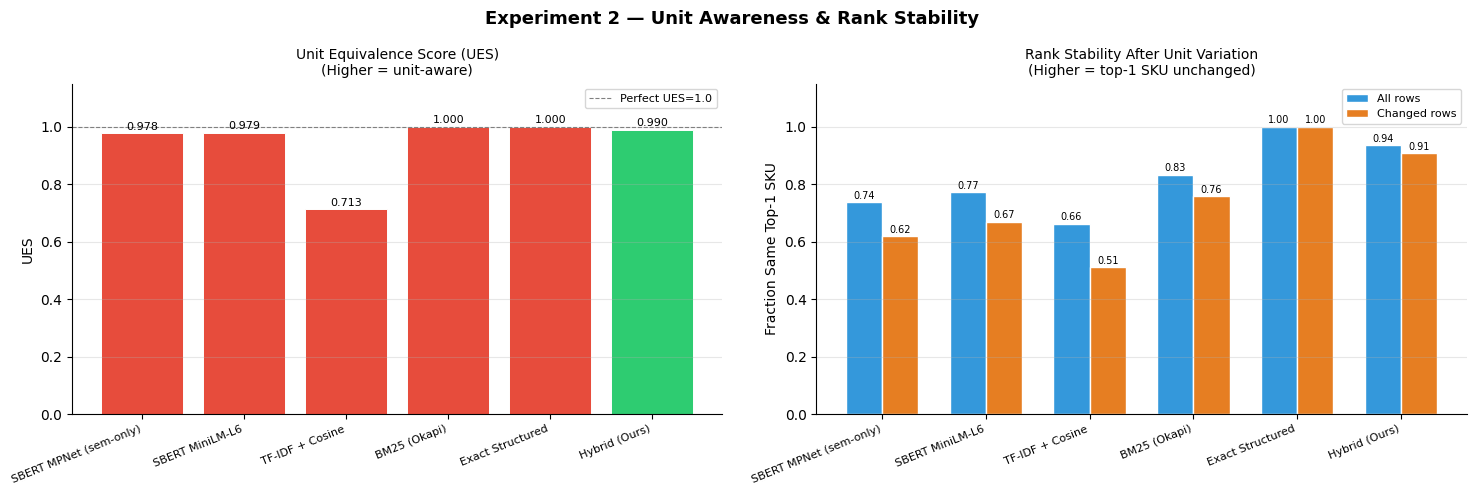

✅ Saved exp2_ues_rank_stability.png


In [ ]:
# CELL 12 — VISUALISATION 1: UES + RANK STABILITY
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
models_list  = overall_df['Model'].tolist()
colors_bar   = ['#2ecc71' if 'Hybrid' in m else '#e74c3c' for m in models_list]
x = np.arange(len(models_list))

ues_vals = overall_df['UES (changed rows)'].values
bars = axes[0].bar(x, ues_vals, color=colors_bar, edgecolor='white', linewidth=0.7)
for bar, val in zip(bars, ues_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)
axes[0].axhline(1.0, color='grey', linestyle='--', linewidth=0.8, label='Perfect UES=1.0')
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace('🏆 ','') for m in models_list], rotation=22, ha='right', fontsize=8)
axes[0].set_title('Unit Equivalence Score (UES)\n(Higher = unit-aware)', fontsize=10)
axes[0].set_ylabel('UES'); axes[0].set_ylim(0, 1.15)
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

rs_all     = overall_df['Rank Stable % (all)'].values
rs_changed = overall_df['Rank Stable % (changed)'].values
w = 0.35
axes[1].bar(x-w/2, rs_all,     w, label='All rows',     color='#3498db', edgecolor='white')
axes[1].bar(x+w/2, rs_changed, w, label='Changed rows', color='#e67e22', edgecolor='white')
for i, (a, c) in enumerate(zip(rs_all, rs_changed)):
    axes[1].text(i-w/2, a+0.005, f'{a:.2f}', ha='center', va='bottom', fontsize=7)
    axes[1].text(i+w/2, c+0.005, f'{c:.2f}', ha='center', va='bottom', fontsize=7)
axes[1].set_xticks(x)
axes[1].set_xticklabels([m.replace('🏆 ','') for m in models_list], rotation=22, ha='right', fontsize=8)
axes[1].set_title('Rank Stability After Unit Variation\n(Higher = top-1 SKU unchanged)', fontsize=10)
axes[1].set_ylabel('Fraction Same Top-1 SKU'); axes[1].set_ylim(0, 1.15)
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)
plt.suptitle('Experiment 2 — Unit Awareness & Rank Stability', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp2_ues_rank_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp2_ues_rank_stability.png')

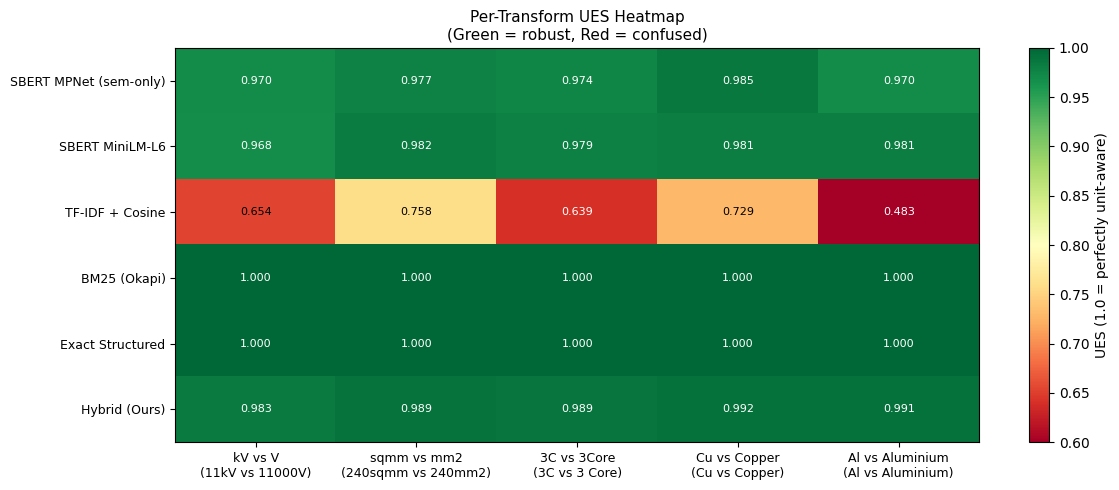

✅ Saved exp2_per_transform_heatmap.png


In [ ]:
# CELL 13 — VISUALISATION 2: PER-TRANSFORM UES HEATMAP
transform_labels = {
    'voltage_unit':  'kV vs V\n(11kV vs 11000V)',
    'area_unit':     'sqmm vs mm2\n(240sqmm vs 240mm2)',
    'core_notation': '3C vs 3Core\n(3C vs 3 Core)',
    'cu_notation':   'Cu vs Copper\n(Cu vs Copper)',
    'al_notation':   'Al vs Aluminium\n(Al vs Aluminium)',
}
tr_keys    = list(transform_labels.keys())
model_lbls = [m.replace('🏆 ','') for m in per_tr_df['Model'].tolist()]
heat_data  = per_tr_df[tr_keys].values.astype(float)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(heat_data, cmap='RdYlGn', aspect='auto', vmin=0.6, vmax=1.0)
ax.set_xticks(range(len(tr_keys)))
ax.set_xticklabels([transform_labels[k] for k in tr_keys], fontsize=9)
ax.set_yticks(range(len(model_lbls)))
ax.set_yticklabels(model_lbls, fontsize=9)
for r in range(len(model_lbls)):
    for c in range(len(tr_keys)):
        val = heat_data[r,c]
        if not np.isnan(val):
            ax.text(c, r, f'{val:.3f}', ha='center', va='center',
                    fontsize=8, color='black' if 0.65 < val < 0.95 else 'white')
plt.colorbar(im, ax=ax, label='UES (1.0 = perfectly unit-aware)')
ax.set_title('Per-Transform UES Heatmap\n(Green = robust, Red = confused)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp2_per_transform_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp2_per_transform_heatmap.png')

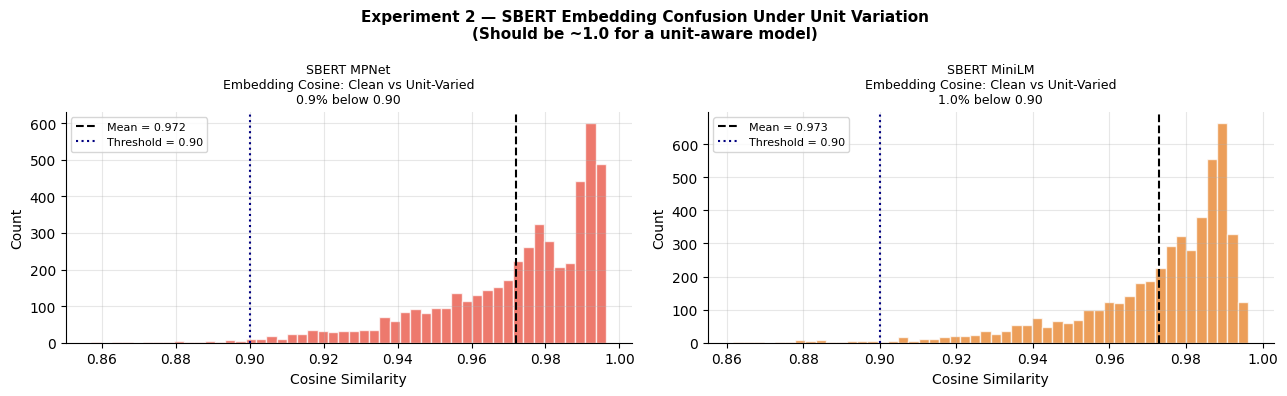

✅ Saved exp2_embedding_cosine_dist.png


In [ ]:
# CELL 14 — VISUALISATION 3: EMBEDDING COSINE DISTRIBUTION
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (cos_vals, model_name, color) in zip(axes, [
    (mpnet_cos,  'SBERT MPNet',  '#e74c3c'),
    (minilm_cos, 'SBERT MiniLM', '#e67e22'),
]):
    ax.hist(cos_vals, bins=50, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(cos_vals.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean = {cos_vals.mean():.3f}')
    ax.axvline(0.90, color='navy', linestyle=':', linewidth=1.5, label='Threshold = 0.90')
    confused_pct = (cos_vals < 0.90).mean() * 100
    ax.set_title(f'{model_name}\nEmbedding Cosine: Clean vs Unit-Varied\n{confused_pct:.1f}% below 0.90', fontsize=9)
    ax.set_xlabel('Cosine Similarity'); ax.set_ylabel('Count')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Experiment 2 — SBERT Embedding Confusion Under Unit Variation\n'
             '(Should be ~1.0 for a unit-aware model)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp2_embedding_cosine_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp2_embedding_cosine_dist.png')

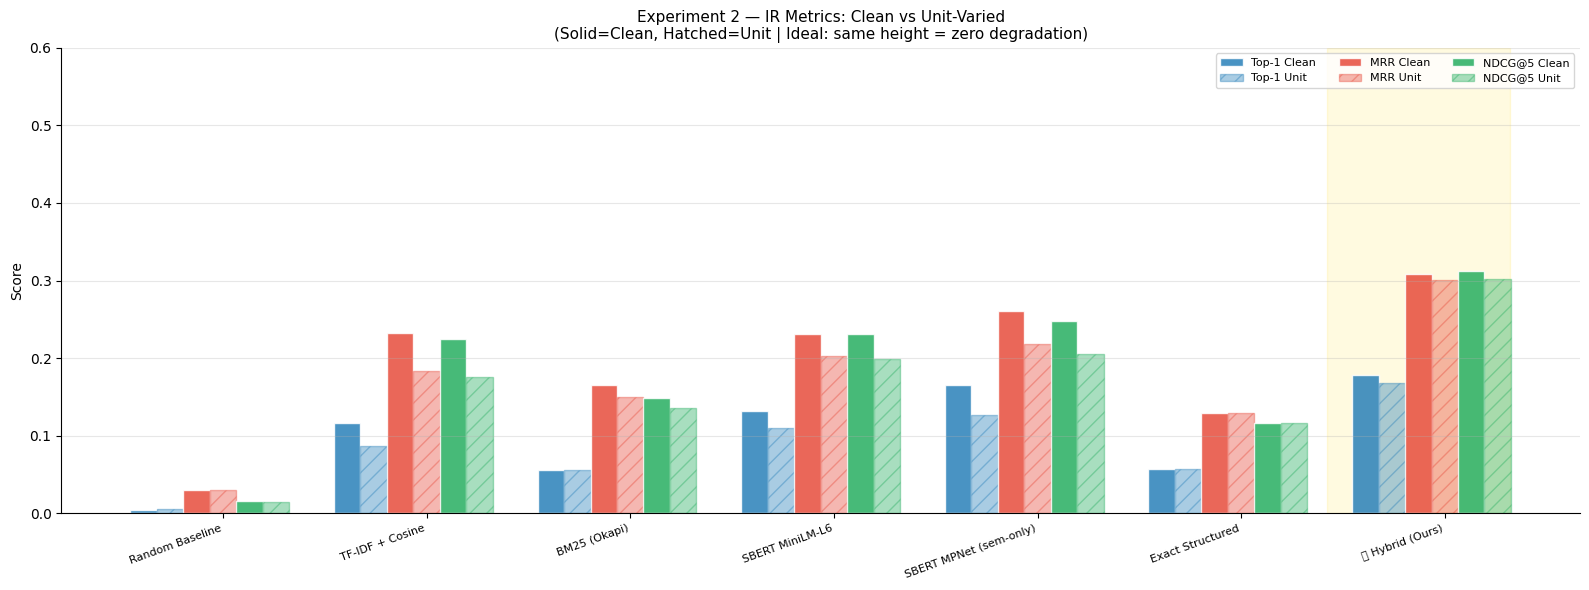

✅ Saved exp2_ir_metrics_comparison.png


In [ ]:
# CELL 15 — VISUALISATION 4: IR METRICS CLEAN vs UNIT
x = np.arange(len(ir_df))
w = 0.13
metric_pairs = [
    ('Top-1 (Clean)','Top-1 (Unit)','Top-1'),
    ('MRR (Clean)',  'MRR (Unit)',  'MRR'),
    ('NDCG@5 (Clean)','NDCG@5 (Unit)','NDCG@5'),
]
palette = ['#2980b9','#e74c3c','#27ae60']
fig, ax = plt.subplots(figsize=(16, 6))
for k, (col_c, col_u, label) in enumerate(metric_pairs):
    offset = (k - 1) * 2 * w
    ax.bar(x+offset,   ir_df[col_c].values, w, color=palette[k], alpha=0.85,
           edgecolor='white', label=f'{label} Clean')
    ax.bar(x+offset+w, ir_df[col_u].values, w, color=palette[k], alpha=0.40,
           edgecolor=palette[k], hatch='//', label=f'{label} Unit')
hybrid_x = [i for i, m in enumerate(ir_df['Model']) if 'Hybrid' in m][0]
ax.axvspan(hybrid_x-0.45, hybrid_x+0.45, color='gold', alpha=0.12, zorder=0)
ax.set_xticks(x+w)
ax.set_xticklabels(ir_df['Model'].tolist(), rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Score'); ax.set_ylim(0, 0.6)
ax.set_title('Experiment 2 — IR Metrics: Clean vs Unit-Varied\n'
             '(Solid=Clean, Hatched=Unit | Ideal: same height = zero degradation)', fontsize=11)
ax.legend(fontsize=8, ncol=3, loc='upper right')
ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp2_ir_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp2_ir_metrics_comparison.png')

In [ ]:
# CELL 16 — CONCRETE FAILURE AND SUCCESS CASES
print('=== SBERT Failure vs Hybrid Success on Unit Variants ===\n')
sbert_sub  = ues_df[(ues_df['model'] == 'SBERT MPNet (sem-only)') & ues_df['any_changed']]
hybrid_sub = ues_df[(ues_df['model'] == '🏆 Hybrid (Ours)')      & ues_df['any_changed']]
sbert_unstable = set(sbert_sub[~sbert_sub['rank_stable']]['rfp_id'])
hybrid_stable  = set(hybrid_sub[hybrid_sub['rank_stable']]['rfp_id'])
hybrid_wins    = sbert_unstable & hybrid_stable
print(f'RFPs where SBERT rank unstable AND Hybrid rank stable: {len(hybrid_wins)}\n')
for rfp_id in sorted(hybrid_wins)[:8]:
    rfp_idx  = df_clean[df_clean['rfp_id'] == rfp_id].index[0]
    tr_info  = tr_df[tr_df['rfp_id'] == rfp_id].iloc[0]
    sb_row   = sbert_sub[sbert_sub['rfp_id']  == rfp_id].iloc[0]
    hy_row   = hybrid_sub[hybrid_sub['rfp_id'] == rfp_id].iloc[0]
    transforms_fired = [t for t in ['voltage_unit','area_unit','core_notation','cu_notation','al_notation'] if tr_info[t]]
    print(f'  RFP: {rfp_id}  |  Transforms: {", ".join(transforms_fired)}')
    print(f'  Clean: {df_clean.loc[rfp_idx,"spec_text_raw"]}')
    print(f'  Unit : {df_unit.loc[rfp_idx,"spec_text_raw"]}')
    print(f'  SBERT  -> clean={sb_row.score_clean:.4f} unit={sb_row.score_unit:.4f} delta={sb_row.delta:+.4f} stable={sb_row.rank_stable} X')
    print(f'  Hybrid -> clean={hy_row.score_clean:.4f} unit={hy_row.score_unit:.4f} delta={hy_row.delta:+.4f} stable={hy_row.rank_stable} OK')
    print()

=== SBERT Failure vs Hybrid Success on Unit Variants ===

RFPs where SBERT rank unstable AND Hybrid rank stable: 1580

  RFP: RFP_0008  |  Transforms: voltage_unit
  Clean: 500V 5C 2.5 sqmm Cu XLPE armoured cable as per IEC 60502-1
  Unit : 0.5kV 5C 2.5 sqmm Cu XLPE armoured cable as per IEC 60502-1
  SBERT  -> clean=0.6793 unit=0.6712 delta=-0.0080 stable=False X
  Hybrid -> clean=0.7321 unit=0.7253 delta=-0.0069 stable=True OK

  RFP: RFP_0013  |  Transforms: voltage_unit, area_unit
  Clean: LSZH 1.1kV 20C 1.5 sqmm Cu XLPE armoured cable as per IEC 60502-1
  Unit : LSZH 1100V 20C 1.5 mm² Cu XLPE armoured cable as per IEC 60502-1
  SBERT  -> clean=0.6574 unit=0.6476 delta=-0.0097 stable=False X
  Hybrid -> clean=0.7143 unit=0.7003 delta=-0.0140 stable=True OK

  RFP: RFP_0017  |  Transforms: core_notation, al_notation
  Clean: FRLS 11kV 1C 300 sqmm Al EPR armoured cable as per IEC 60502-1
  Unit : FRLS 11kV 1 Core 300 sqmm Aluminium EPR armoured cable as per IEC 60502-1
  SBERT  -> cl

In [ ]:
# CELL 17 — FINAL SUMMARY (PAPER-READY)
print('\n' + '='*110)
print('  EXPERIMENT 2 — UNIT VARIATION TEST: COMPLETE RESULTS SUMMARY')
print('='*110)
print('\n-- Section A: UES & Stability --')
print(overall_df.to_markdown(index=False, floatfmt='.4f'))
print('\n-- Section B: IR Metrics (Clean to Unit-Varied) --')
print(ir_df[['Model','Top-1 (Clean)','Top-1 (Unit)','Δ Top-1',
              'MRR (Clean)','MRR (Unit)','Δ MRR',
              'NDCG@5 (Clean)','NDCG@5 (Unit)','Δ NDCG@5']]
      .to_markdown(index=False, floatfmt='.4f'))
print('\n-- Section C: Embedding Confusion Direct Probe --')
print(f'  MPNet  cosine clean vs unit: mean={mpnet_cos.mean():.4f}  confused (<0.90): {(mpnet_cos<0.90).mean()*100:.1f}%')
print(f'  MiniLM cosine clean vs unit: mean={minilm_cos.mean():.4f}  confused (<0.90): {(minilm_cos<0.90).mean()*100:.1f}%')
print(f'  Hybrid structured component: cosine = 1.000 (identical columns, zero confusion)')
h_ir  = ir_df[ir_df['Model'].str.contains('Hybrid')].iloc[0]
s_ir  = ir_df[ir_df['Model'].str.contains('MPNet')].iloc[0]
h_ues = overall_df[overall_df['Model'].str.contains('Hybrid')].iloc[0]
s_ues = overall_df[overall_df['Model'].str.contains('MPNet')].iloc[0]
h_ret = h_ir['Top-1 (Unit)'] / h_ir['Top-1 (Clean)'] if h_ir['Top-1 (Clean)'] > 0 else 0
s_ret = s_ir['Top-1 (Unit)'] / s_ir['Top-1 (Clean)'] if s_ir['Top-1 (Clean)'] > 0 else 0
print('\n-- Key Findings --')
print(f'  Hybrid retains {h_ret*100:.1f}% of Top-1 under unit variation')
print(f'  SBERT  retains {s_ret*100:.1f}% of Top-1 under unit variation')
print(f'  Hybrid UES: {h_ues["UES (changed rows)"]:.4f}  SBERT UES: {s_ues["UES (changed rows)"]:.4f}')
print(f'  Hybrid rank stable (changed): {h_ues["Rank Stable % (changed)"]*100:.1f}%')
print(f'  SBERT  rank stable (changed): {s_ues["Rank Stable % (changed)"]*100:.1f}%')
print(f'  RFPs where Hybrid correct, SBERT wrong: {len(hybrid_wins)}')


  EXPERIMENT 2 — UNIT VARIATION TEST: COMPLETE RESULTS SUMMARY

-- Section A: UES & Stability --
| Model                  |   UES (changed rows) |   Avg |ΔScore| |   Avg ΔScore |   Rank Stable % (all) |   Rank Stable % (changed) |
|:-----------------------|---------------------:|---------------:|-------------:|----------------------:|--------------------------:|
| SBERT MPNet (sem-only) |               0.9781 |         0.0156 |      -0.0113 |                0.7364 |                    0.6181 |
| SBERT MiniLM-L6        |               0.9791 |         0.0135 |      -0.0009 |                0.7717 |                    0.6692 |
| TF-IDF + Cosine        |               0.7129 |         0.0318 |      -0.0226 |                0.6624 |                    0.5109 |
| BM25 (Okapi)           |               1.0000 |         0.0000 |       0.0000 |                0.8334 |                    0.7586 |
| Exact Structured       |               1.0000 |         0.0000 |       0.0000 |                1

In [ ]:
# CELL 18 — EXPORT
overall_df.to_csv(f'{EXP_DIR}/exp2_ues_summary.csv', index=False)
per_tr_df.to_csv(f'{EXP_DIR}/exp2_per_transform_ues.csv', index=False)
ir_df.to_csv(f'{EXP_DIR}/exp2_ir_metrics_clean_vs_unit.csv', index=False)
ues_df.to_csv(f'{EXP_DIR}/exp2_per_rfp_ues.csv', index=False)
np.save(f'{EXP_DIR}/mpnet_cosine_clean_vs_unit.npy', mpnet_cos)
np.save(f'{EXP_DIR}/minilm_cosine_clean_vs_unit.npy', minilm_cos)
print('✅ Saved:')
for f in sorted(os.listdir(EXP_DIR)):
    size = os.path.getsize(f'{EXP_DIR}/{f}') / 1024
    print(f'   {EXP_DIR}/{f}  ({size:.0f} KB)')

✅ Saved:
   exp2_unit_variation/exp2_embedding_cosine_dist.png  (84 KB)
   exp2_unit_variation/exp2_ir_metrics_clean_vs_unit.csv  (2 KB)
   exp2_unit_variation/exp2_ir_metrics_comparison.png  (119 KB)
   exp2_unit_variation/exp2_per_rfp_ues.csv  (5099 KB)
   exp2_unit_variation/exp2_per_transform_heatmap.png  (102 KB)
   exp2_unit_variation/exp2_per_transform_ues.csv  (1 KB)
   exp2_unit_variation/exp2_ues_rank_stability.png  (103 KB)
   exp2_unit_variation/exp2_ues_summary.csv  (1 KB)
   exp2_unit_variation/minilm_cosine_clean_vs_unit.npy  (19 KB)
   exp2_unit_variation/mpnet_cosine_clean_vs_unit.npy  (19 KB)
